# Collect datasets relevant for priority case study area in Nairobi, Kenya

Urban, temperature, lst, flooding (wofs), population density, elevation, land cover, cropping, mangrove/vegetation


Admin boundary + Land cover to determine urban areas

Exposure to high temp, flooding, other?

High Population density or settlement types (by combining density and land cover?)

Total quota for skysat 153 km²


In [1]:
import geopandas as gpd
import numpy as np
import os
import rioxarray as rxr
import xarray as xr
from scipy.ndimage.morphology import binary_closing

import datacube
from deafrica_tools.datahandling import load_ard, mostcommon_crs
from odc.geo.geom import Geometry
from deafrica_tools.load_era5 import load_era5
from deafrica_tools.spatial import xr_rasterize, xr_vectorize
from datacube.utils.cog import write_cog


/tmp/ipykernel_535/4020960582.py:6: DeprecationWarning: Please import `binary_closing` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_closing


In [2]:
# Nairobi boundary and constituency

gdf = gpd.read_file('gadm41_KEN_2.json')
gdf = gdf[gdf.NAME_1=='Nairobi']
gdf.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
190,KEN.30.1_1,KEN,Kenya,KEN.30_1,Nairobi,NA,DagorettiNorth,NA,NA,Constituency,Constituency,275,NA,"MULTIPOLYGON (((36.7608 -1.2682, 36.7597 -1.26..."
191,KEN.30.2_1,KEN,Kenya,KEN.30_1,Nairobi,NA,DagorettiSouth,NA,NA,Constituency,Constituency,276,NA,"MULTIPOLYGON (((36.7538 -1.2918, 36.7564 -1.29..."
192,KEN.30.3_1,KEN,Kenya,KEN.30_1,Nairobi,NA,EmbakasiCentral,NA,NA,Constituency,Constituency,284,NA,"MULTIPOLYGON (((36.9181 -1.2803, 36.9148 -1.28..."
193,KEN.30.4_1,KEN,Kenya,KEN.30_1,Nairobi,NA,EmbakasiEast,NA,NA,Constituency,Constituency,285,NA,"MULTIPOLYGON (((36.9756 -1.2916, 36.9836 -1.31..."
194,KEN.30.5_1,KEN,Kenya,KEN.30_1,Nairobi,NA,EmbakasiNorth,NA,NA,Constituency,Constituency,283,NA,"MULTIPOLYGON (((36.8937 -1.2556, 36.8884 -1.25..."


In [3]:
gdf_dissolved = gdf.dissolve(by='NAME_1')
gdf_dissolved = gdf_dissolved.reset_index()
gdf_aoi = gdf_dissolved[gdf_dissolved.NAME_1=='Nairobi']

In [4]:
gdf.to_crs('EPSG:6933').area/1e6

190     26.763409
191     28.973864
192      8.336429
193     85.593890
194      5.425634
195     17.742750
196      9.718207
197      8.661901
198    136.124436
199     13.383481
200    209.256229
201     12.113175
202      2.939086
203     47.667589
204      7.251026
205     16.827508
206     75.379766
dtype: float64

In [5]:
lat_range = (gdf.total_bounds[1], gdf.total_bounds[3])
lon_range = (gdf.total_bounds[0], gdf.total_bounds[2])

In [56]:
os.environ['AWS_DEFAULT_REGION']="af-south-1"
os.environ['AWS_S3_ENDPOINT']="s3.af-south-1.amazonaws.com"

## Land surface temperature

In [7]:
dc = datacube.Datacube()

In [8]:
geom = Geometry(gdf.dissolve().geometry[0], crs=gdf.crs)

query = {
    "geopolygon": geom,
}

In [9]:
output_crs = mostcommon_crs(dc, "ls8_st", query)

/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:762: UserWarning: Multiple UTM zones ['epsg:32637', 'epsg:32636'] were returned for this query. Defaulting to the most common zone: epsg:32637
  warnings.warn(


In [63]:
time = "2023", "2025"
time = "2014", "2017"

lst = load_ard(
    dc=dc,
    products=["ls8_st", "ls9_st"],
    min_gooddata=0.9,
    time=time,
    group_by="solar_day",
    measurements=["surface_temperature", "surface_temperature_quality"],
    output_crs=output_crs,
    resolution=(-30, 30),
    dask_chunks={"x": 3000, "y": 3000},
    **query    
)

Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_st
    ls9_st
Counting good quality pixels for each time step
Filtering to 13 out of 89 time steps with at least 90.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 13 time steps as a dask array


In [64]:
lst.time

<xarray.DataArray 'time' (time: 13)> Size: 104B
array(['2014-02-03T07:44:13.277972000', '2014-09-15T07:43:19.543442000',
       '2014-12-20T07:43:18.718916000', '2015-01-05T07:43:13.910847000',
       '2016-01-24T07:43:16.005437000', '2016-02-25T07:43:04.887145000',
       '2016-03-28T07:42:52.830250000', '2016-08-03T07:43:12.496126000',
       '2017-01-10T07:43:22.034171000', '2017-01-26T07:43:16.519609000',
       '2017-02-11T07:43:08.367981000', '2017-10-09T07:43:27.542825000',
       '2017-12-28T07:43:21.518923000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 104B 2014-02-03T07:44:13.277972 ... 20...
    spatial_ref  int32 4B 32637
Attributes:
    units:    seconds since 1970-01-01 00:00:00

In [65]:
lst = lst.dropna(dim='time', how='all')
lst['surface_temperature'] = lst.surface_temperature - 273.15

In [66]:
aoi_mask = xr_rasterize(gdf=gdf_aoi,
                                  da=lst.surface_temperature,
                                  #transform=lst.surface_temperature.geobox.transform,
                                  crs=lst.crs)

In [67]:
def weighted_mean(ds):
    weights = 1 / (ds.surface_temperature_quality + 1e-6)
    weighted_sum = (ds.surface_temperature * weights).sum(dim="time")
    weight_total = weights.sum(dim="time")
    return weighted_sum / weight_total  # Return the result!

# Apply monthly weighted mean
monthly_weighted_mean = lst.groupby("time.month").apply(weighted_mean)


In [68]:
monthly_weighted_mean=monthly_weighted_mean.compute()

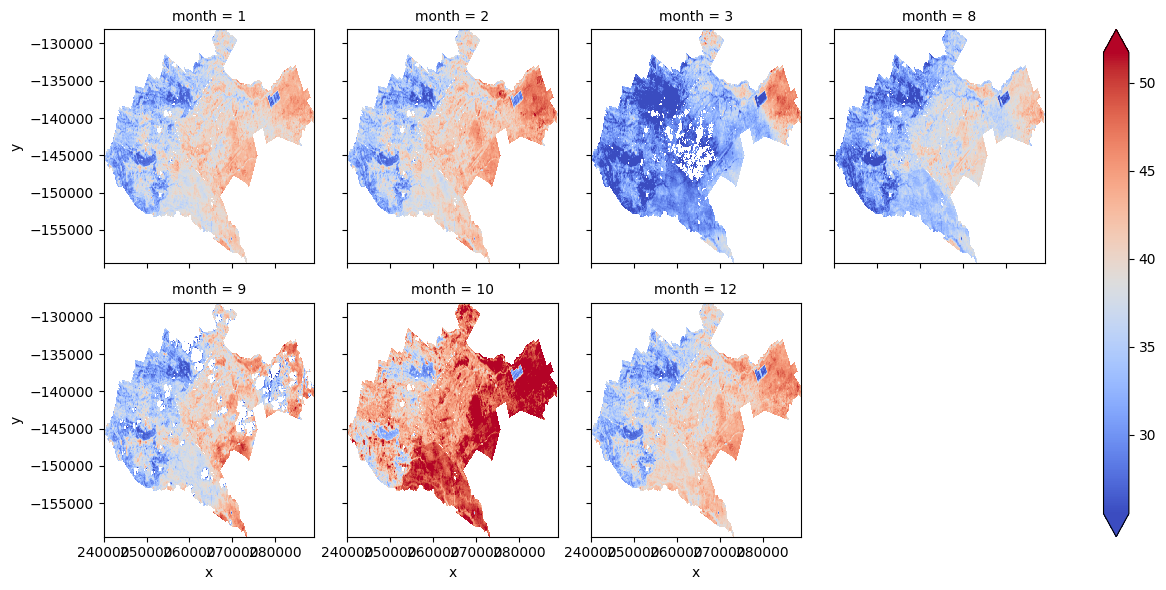

In [69]:
monthly_weighted_mean.where(aoi_mask).plot.imshow(col='month', col_wrap=4, robust=True, cmap="coolwarm")

In [70]:
write_cog(monthly_weighted_mean.where(aoi_mask).sel(month=2),
          fname="nairobi_lst_feb_2014_2017.tif",
          overwrite=True)

PosixPath('nairobi_lst_feb_2014_2017.tif')

In [23]:
lat_range = (gdf.total_bounds[1], gdf.total_bounds[3])
lon_range = (gdf.total_bounds[0], gdf.total_bounds[2])
time = "2024-01", "2025-12"

In [24]:
var = "air_temperature_at_2_metres"

#temp = load_era5(var, lat_range, lon_range, time, reduce_func=np.mean, resample="1ME").compute()
#temp = temp - 273.15  # convert from Kelvin to Celcius

In [25]:
#temp[var].mean(['lat','lon']).groupby("time.month").mean().plot()

## Elevation

In [26]:
# Load elevation data
mrvbf = dc.load(product="dem_srtm_deriv", measurements=["mrvbf"], like=lst.geobox).mrvbf.squeeze()
elev = dc.load(product="dem_srtm", measurements=["elevation"], like=lst.geobox).elevation.squeeze()

In [27]:
write_cog(mrvbf.where(aoi_mask),
          fname="nairobi_mrvbf.tif",
          overwrite=True)
write_cog(elev.where(aoi_mask),
          fname="nairobi_elev.tif",
          overwrite=True)

PosixPath('nairobi_elev.tif')

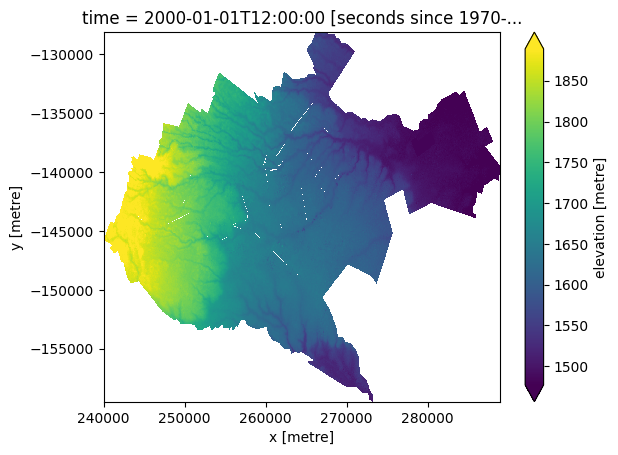

In [28]:
elev.where(aoi_mask).plot.imshow(robust=True);

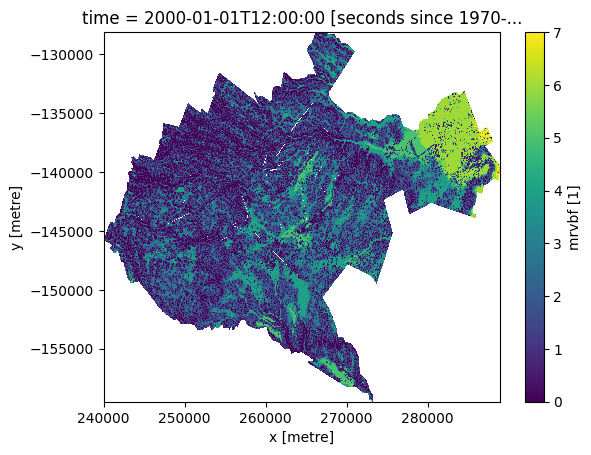

In [29]:
mrvbf.where(aoi_mask).plot.imshow();

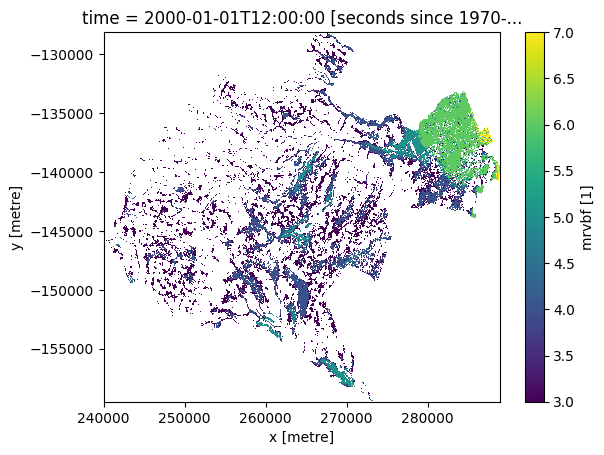

In [30]:
(mrvbf.where(aoi_mask).where(mrvbf>2)).plot.imshow()

In [79]:
# Load elevation data
wofs = dc.load(product="wofs_ls_summary_alltime", like=lst.geobox)#.mrvbf.squeeze()


In [81]:
write_cog(wofs.frequency.squeeze().where(aoi_mask),
          fname="nairobi_wofs_freq.tif",
          overwrite=True)

PosixPath('nairobi_wofs_freq.tif')

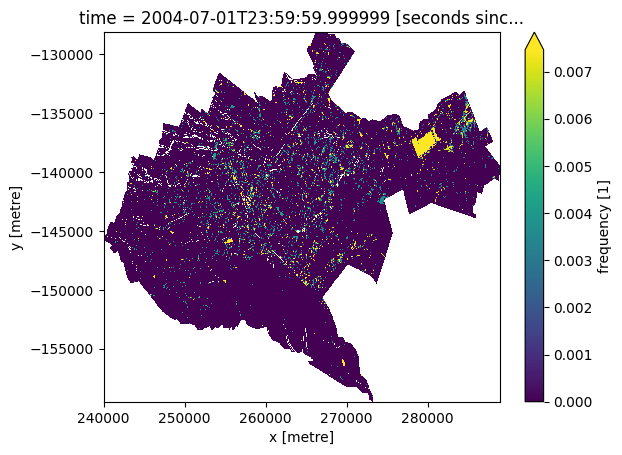

In [83]:
wofs.frequency.squeeze().where(aoi_mask).plot.imshow(robust=True)

## Population

In [31]:
os.environ['AWS_DEFAULT_REGION']="us-east-1"
os.environ['AWS_S3_ENDPOINT']="s3.us-east-1.amazonaws.com"
# Load population data
ds = rxr.open_rasterio('s3://dataforgood-fb-data/hrsl-cogs/hrsl_general/hrsl_general-latest.vrt', 
                       chunks ={'x': 1000, 'y': 1000})
ds = ds.rename({'x':'longitude','y':'latitude'})

pop_raster = ds.isel(band=0).sel(longitude=slice(gdf.total_bounds[0], gdf.total_bounds[2]), latitude = slice(gdf.total_bounds[3], gdf.total_bounds[1])).compute()

In [38]:
aoi_pop_mask = xr_rasterize(gdf=gdf_aoi,
                                  da=pop_raster,
                                  #transform=lst.surface_temperature.geobox.transform,
                                  crs=pop_raster.rio.crs)

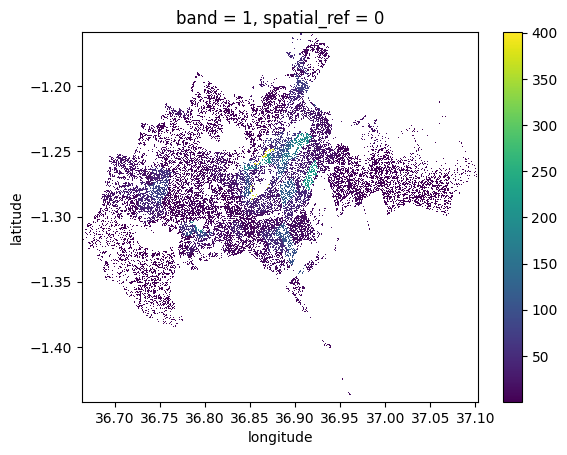

In [45]:
pop_raster.where(aoi_pop_mask.values).plot.imshow()

In [71]:
write_cog(pop_raster.where(aoi_pop_mask.values),
          fname="nairobi_hrsl.tif",
          overwrite=True)

PosixPath('nairobi_hrsl.tif')

In [51]:
closed = binary_closing((pop_raster.where(aoi_pop_mask.values)>30).values,iterations=10).astype(np.uint8)
pop_closed = pop_raster.copy()
pop_closed.values = closed

In [52]:
urban = xr_vectorize(pop_closed, mask=pop_closed).to_crs(lst.crs)
urban.explore()

In [72]:
closed = binary_closing((monthly_weighted_mean.where(aoi_mask).sel(month=2)>40).values,iterations=10).astype(np.uint8)
lst_closed = monthly_weighted_mean.sel(month=2).copy()
lst_closed.values = closed

uhi = xr_vectorize(lst_closed, mask=lst_closed).to_crs(lst.crs)
uhi.explore()

In [74]:
#closed = binary_closing((mrvbf>2).values,iterations=1).astype(np.uint8)
closed = (mrvbf.where(aoi_mask)>3).values
mrvbf_closed = mrvbf.copy()
mrvbf_closed.values = closed

low = xr_vectorize(mrvbf_closed, mask=mrvbf_closed).to_crs(lst.crs)
low.explore()